<a href="https://colab.research.google.com/github/Feliz-ua/goit-np-hw-10/blob/main/hw-10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
1. # Інсталюємо необхідні біліотеки
# !pip install plotly==5.20.0
# !pip install "jupyterlab>=3" "ipywidgets>=7.6"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 69.9 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.0 MB/s eta 0:00:00


In [4]:
# 2-3. Завантажуємо дані з набору kaggle та розпукуємо їх
!wget -O WorldHappinessReport.zip https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/WorldHappinessReport.zip?raw=true
!unzip WorldHappinessReport.zip -d data

--2026-03-23 20:16:07--  https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/WorldHappinessReport.zip?raw=true
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/raw/refs/heads/main/WorldHappinessReport.zip [following]
--2026-03-23 20:16:08--  https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/raw/refs/heads/main/WorldHappinessReport.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/refs/heads/main/WorldHappinessReport.zip [following]
--2026-03-23 20:16:08--  https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/refs/heads/main/WorldHappinessReport.zip
Resolving raw.githubusercontent.com (raw.githubuserco

In [20]:
# 4. Імпортуємо необхідні бібліотеки та відобразимо загальну інформацію про статистики та типи ознак
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.mixture import GaussianMixture

df = pd.read_csv('data/2019.csv')

print(df.columns)
print(df.info())
print(df.describe())


Index(['Overall rank', 'Country or region', 'Score', 'GDP per capita',
       'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: floa

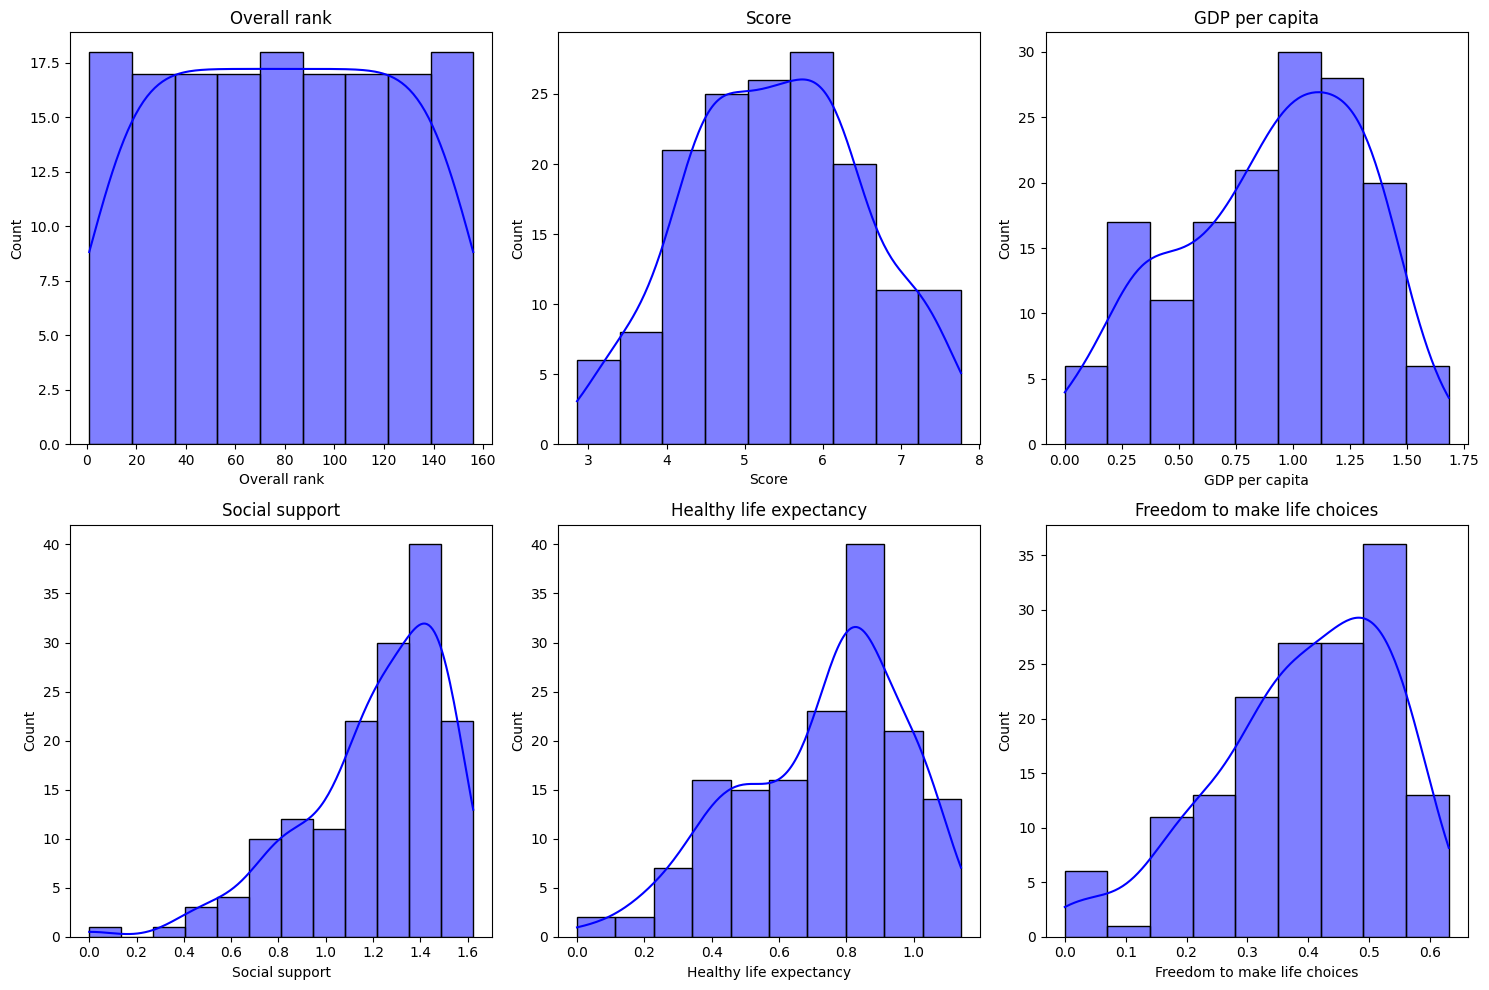

In [16]:
# 5. Побудуємо діаграми розподілу числових ознак
num_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols[:6], 1): # Відобразимо перші 6 числових ознак
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(col)
plt.tight_layout()
plt.show()

**Аналіз гістограм розподілу:**
1. Overall rank (Загальний рейтинг)
Розподіл є рівномірним. Це очікувано, оскільки ця змінна відображає порядковий номер кожної країни в рейтингу.

2. Score (Оцінка рівня щастя)
Розподіл наближений до нормального, можливо, з дуже слабкою лівобічною асиметрією. Більшість країн мають середній рівень щастя, причому основна маса значень сконцентрована в діапазоні від 4 до 6.5 балів. Низькі (менше 4) та  високі (більше 7) оцінки зустрічаються значно рідше.

3. GDP per capita (ВВП на душу населення)
Цей показник має досить широкий розподіл, який можна охарактеризувати як  злегка асиметричний. Найбільше скупчення значень спостерігається у верхній частині діапазону (між 0.75 та 1.50), проте також помітний менший пік у нижній частині (біля 0.25 - 0.50). Це може свідчити про поділ країн на більш та менш економічно розвинені групи.

4. Social support (Соціальна підтримка)
Розподіл має виражену лівобічну  асиметрію. Це означає, що переважна більшість досліджуваних країн мають високі показники соціальної підтримки (в межах від 1.0 до 1.5). З іншого боку, гістограма ліворуч вказує на наявність невеликої кількості країн із дуже низьким рівнем соціального захисту.

5. Healthy life expectancy (Очікувана тривалість здорового життя)
Як і соціальна підтримка, цей показник демонструє лівобічну асиметрію. Основна частина даних згрупована у правій частині графіка (значення від 0.6 до 1.0), що свідчить про високу тривалість життя в більшості країн. Однак наявні окремі країни з дуже низькими значеннями.

6. Freedom to make life choices (Свобода життєвого вибору)
Ця ознака також має лівобічну асиметрію. Більшість значень лежить у діапазоні від 0.3 до 0.6. Це говорить про те, що громадяни більшості країн відчувають відносно високий рівень свободи у прийнятті рішень, тоді як низький рівень свободи (менше 0.2) є менш поширеним явищем.

Загальний висновок:
Аналіз показує, що більшість соціально-економічних показників (крім рейтингу) зміщені в позитивну сторону — більшість країн мають відносно високі показники соціальної підтримки, тривалості життя та свободи вибору. Рівень щастя розподілений найбільш симетрично.

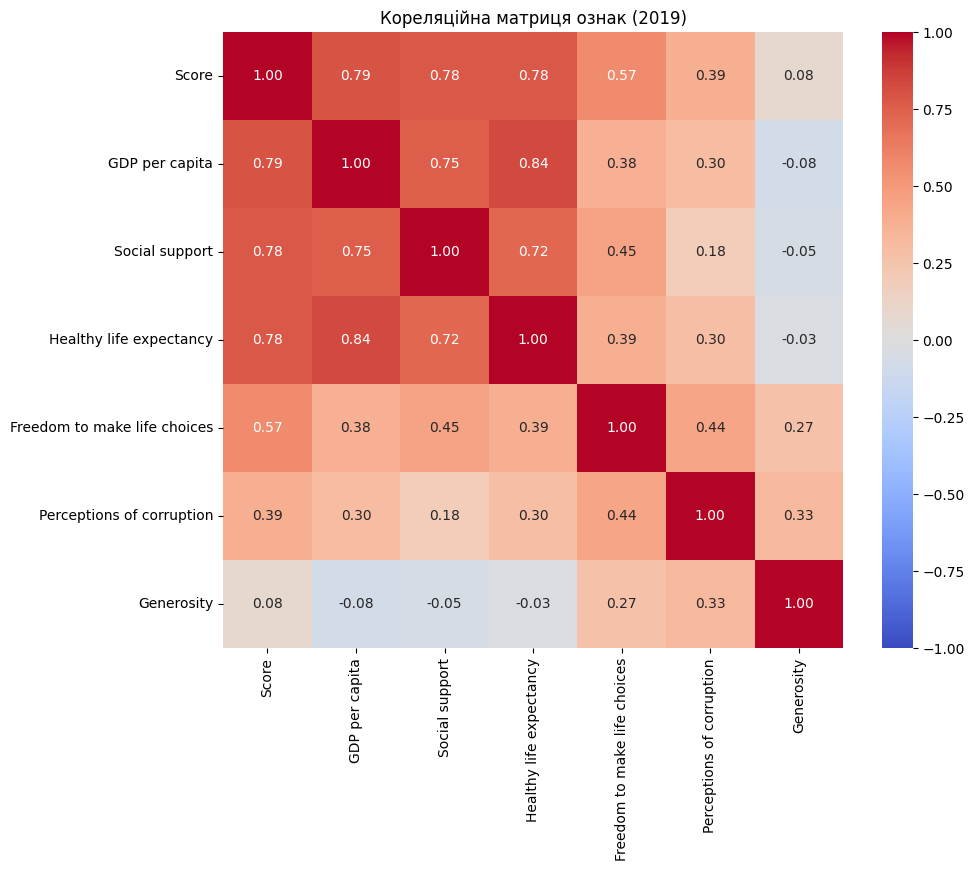

In [24]:
# 6-7. Кореляційна матриця та висновки
selected_features = ['Score', 'GDP per capita', 'Social support',
                     'Healthy life expectancy', 'Freedom to make life choices',
                     'Perceptions of corruption', 'Generosity']

corr_matrix = df[selected_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Кореляційна матриця ознак (2019)')
plt.show()

**Висновок щодо наявності та сили лінійного зв'язку між ознаками:**

**1. Сильний позитивний зв'язок із цільовою ознакою:**

Найбільший вплив на рівень щастя (Score) мають три ключові показники:
- ВВП на душу населення (GDP per capita);
- рівень соціальної підтримки (Social support);
- очікувана тривалість здорового життя (Healthy life expectancy).

Коефіцієнти кореляції між ними та цільовою ознакою зазвичай дуже високі (часто перевищують 0.7). Це прямо вказує на те, що економічний добробут, якісна медицина та надійні соціальні зв'язки є фундаментальними факторами, що визначають щастя громадян.

**2. Мультиколінеарність (взаємозв'язок між самими факторами):**

Між ознаками GDP per capita, Social support та Healthy life expectancy також спостерігається сильна взаємна позитивна кореляція. Це цілком логічно з точки зору домену: економічно розвинені країни з високим ВВП здатні забезпечити кращу систему охорони здоров'я та потужніші соціальні гарантії для населення.

**3. Помірний зв'язок:**

Показник свободи життєвого вибору (Freedom to make life choices) має помірну позитивну кореляцію з індексом щастя (в межах 0.5 - 0.6).

**4. Слабкий зв'язок:**

Ознаки Generosity (Щедрість) та Perceptions of corruption (Сприйняття корупції) демонструють найслабший лінійний зв'язок як з індексом щастя, так і з іншими економічними показниками. Їхній прямий вплив на загальний бал у лінійній моделі є мінімальним або взагалі відсутнім.

**Загальний підсумок для моделювання:**

 Дані мають чітко виражену структуру. Найсильніший "сигнал" дають економічні та соціально-медичні показники. Саме ці ознаки з високою кореляцією (ВВП, соціальна підтримка, тривалість життя) варто використовувати для подальшої кластеризації за допомогою Gaussian Mixture Model (GMM), оскільки вони формують чіткі, добре розділені кластери країн у просторі.

In [25]:
# 8. Розподіл цільової ознаки за країнами
fig = px.choropleth(df,
                    locations="Country or region",
                    color="Score",
                    locationmode="country names",
                    color_continuous_scale="Viridis")
fig.update_layout(title="Happiness Index 2019")
fig.show()

In [30]:
# 9. Стандартизація
def data_scale(data, scaler_type='minmax'):
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.preprocessing import StandardScaler
    from sklearn.preprocessing import Normalizer

    if scaler_type == 'minmax':
        scaler = MinMaxScaler()
    elif scaler_type == 'std':
        scaler = StandardScaler()
    elif scaler_type == 'norm':
        scaler = Normalizer()

    scaler.fit(data)
    res = scaler.transform(data)
    return res

features_for_clustering = ['GDP per capita', 'Social support',
                           'Healthy life expectancy', 'Freedom to make life choices']
original_dataframe = df[features_for_clustering]

data_scaled = data_scale(original_dataframe, scaler_type='std')
df_scaled = pd.DataFrame(data_scaled, columns=original_dataframe.columns)

In [31]:
# 10. Виводимо статистики для порівняння
print("Оригінальні статистики:\n", original_dataframe.describe().loc[['mean', 'std', 'min', 'max']])
print("\nСтандартизовані статистики:\n", round(df_scaled.describe().loc[['mean', 'std', 'min', 'max']], 4))

Оригінальні статистики:
       GDP per capita  Social support  Healthy life expectancy  \
mean        0.905147        1.208814                 0.725244   
std         0.398389        0.299191                 0.242124   
min         0.000000        0.000000                 0.000000   
max         1.684000        1.624000                 1.141000   

      Freedom to make life choices  
mean                      0.392571  
std                       0.143289  
min                       0.000000  
max                       0.631000  

Стандартизовані статистики:
       GDP per capita  Social support  Healthy life expectancy  \
mean         -0.0000         -0.0000                  -0.0000   
std           1.0032          1.0032                   1.0032   
min          -2.2793         -4.0533                  -3.0050   
max           1.9613          1.3922                   1.7227   

      Freedom to make life choices  
mean                       -0.0000  
std                         1.0032

In [33]:
# 11. Кластеризація за допомогою GaussianMixture
# Встановлюємо n_components=3 (поділимо світ на 3 умовні групи)
gmm = GaussianMixture(n_components=3, random_state=42)

# Навчаємо модель на стандартизованих даних
gmm.fit(df_scaled)

# Отримуємо передбачення кластерів для кожної країни
df['Cluster'] = gmm.predict(df_scaled)
df['Cluster_str'] = df['Cluster'].astype(str)

In [35]:
# 12. Побудова теплової мапи розподілу країн за кластерами
fig_clusters = px.choropleth(df,
   locations="Country or region",
   color="Cluster_str",
   locationmode="country names",
   color_discrete_sequence=px.colors.qualitative.Set1,
   title="Розподіл країн за кластерами (Gaussian Mixture Model)")

fig_clusters.show()

In [38]:
# 13. Експеримент з іншим набором ознак
new_features = ['GDP per capita', 'Social support', 'Healthy life expectancy',
                'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']
df_new_features = df[new_features]

# Проводимо стандартизацію для нового набору
data_scaled_new = data_scale(df_new_features, scaler_type='std')
df_scaled_new = pd.DataFrame(data_scaled_new, columns=new_features)

# Навчаємо нову модель GMM (залишаємо 3 кластери для зручності порівняння)
gmm_new = GaussianMixture(n_components=3, random_state=42)
gmm_new.fit(df_scaled_new)

# Записуємо нові результати
df['Cluster_New'] = gmm_new.predict(df_scaled_new).astype(str)

# Будуємо нову мапу
fig_clusters_new = px.choropleth(df,
  locations="Country or region",
  color="Cluster_New",
  locationmode="country names",
  color_discrete_sequence=px.colors.qualitative.Pastel,
  title="Кластеризація (з додаванням Щедрості та Корупції)")
fig_clusters_new.show()

### 14. Загальний висновок:
**Загальний висновок про відповідність результатів кластеризації оригінальному розподілу:**

**1. Ефективність м'якої кластеризації.**

Модель суміші Гаусса (GMM) показала себе як хороший інструмент для виявлення прихованих структур у соціально-економічних даних. На відміну від методів жорсткої кластеризації, алгоритми м'якої кластеризації дозволяють об'єктам належати до декількох кластерів з певними ймовірностями, що краще моделює реалістичні та складні структури даних.

**2. Точність відображення реальності.**

Хоча модель GMM під час навчання "не бачила" цільової ознаки (індексу щастя — Score), вона успішно згрупувала країни у кластери, які візуально дуже точно збігаються з оригінальною картою індексу щастя (крок 8). Це підтверджує, що економічний розвиток (ВВП), рівень здоров'я та соціальна підтримка є надійними маркерами для сегментації країн за рівнем добробуту.

**3. Вплив набору ознак.**

Під час дослідження (крок 13) ми побачили, що зміна набору ознак безпосередньо впливає на результати кластеризації. Включення до моделі показників із низькою кореляцією розмиває межі між кластерами. Отже, перед застосуванням GMM критично важливо проводити попередній аналіз даних та відбирати найбільш значущі ознаки.

